In [31]:
"""Tabular baseline notebook using shared src preprocessing + model helpers."""

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Ensure src is on path for shared constants and helpers
ROOT = Path.cwd().parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

NOTEBOOK_DIR = Path.cwd()
ARTIFACT_ROOT = NOTEBOOK_DIR / "artifacts" / "baseline"
CHECKPOINT_DIR = ARTIFACT_ROOT / "checkpoints"
RESULTS_DIR = ARTIFACT_ROOT / "results"
PLOTS_DIR = ARTIFACT_ROOT / "plots"
CONFIG_SNAPSHOT_PATH = RESULTS_DIR / "config.json"
for _p in (ARTIFACT_ROOT, CHECKPOINT_DIR, RESULTS_DIR, PLOTS_DIR):
    _p.mkdir(parents=True, exist_ok=True)

from data.constants import CAT_COLS, LOG_COLS, NUMERIC_COLS, TARGET_COL
import data.encode_features as enc
from models.train import TrainConfig, make_loaders, train_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Notebook Overview
- Build tabular baseline using shared preprocessing and model helpers from `src`.
- Save artifacts under `notebooks/artifacts/baseline/` (`checkpoints`, `results`, `plots`).
- Train shared tabular regressor, log metrics, and export model/config/results for reuse.

In [32]:
# Load processed splits and build feature matrices
from torch.utils.data import DataLoader, TensorDataset

data_dir = ROOT / "data" / "processed" / "all_features"

train_df = pd.read_csv(data_dir / "train.csv")
val_df = pd.read_csv(data_dir / "val.csv")
test_df = pd.read_csv(data_dir / "test.csv")

(
    X_train_np,
    X_val_np,
    X_test_np,
    y_train_np,
    y_val_np,
    y_test_np,
    artifacts,
) = enc.prepare_features(train_df, val_df, test_df)

input_dim = X_train_np.shape[1]
print(f"Input dim (shared): {input_dim}")
print(f"Train/val/test shapes: {X_train_np.shape}, {X_val_np.shape}, {X_test_np.shape}")

# Build loaders for shared (concatenated) features
batch_size = 256
train_loader, val_loader = make_loaders(
    X_train_np,
    y_train_np,
    X_val_np,
    y_val_np,
    batch_size=batch_size,
    separate=False,
)

test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test_np), torch.from_numpy(y_test_np)),
    batch_size=batch_size,
    shuffle=False,
)

Input dim (shared): 12
Train/val/test shapes: (3804, 12), (815, 12), (816, 12)


In [34]:
# Train a shared tabular regressor using src/models
cfg = TrainConfig(
    mode="shared",
    input_dim=input_dim,
    encoder_hidden=(256, 128, 64),
    head_hidden=(),
    dropout=0.1,
    lr=1e-3,
    epochs=200,
    batch_size=batch_size,
    device=str(device),
)

model, history = train_model(cfg, train_loader, val_loader, X_is_separate=False)
model = model.to(device).eval()

Epoch 001 | train MSE 274.5871 | val MSE 215.8423 | train MAE 16.4280 | val MAE 14.5414
Epoch 010 | train MSE 6.8645 | val MSE 3.7096 | train MAE 2.0660 | val MAE 1.4499
Epoch 020 | train MSE 4.1347 | val MSE 1.8738 | train MAE 1.6217 | val MAE 1.0457
Epoch 030 | train MSE 3.3057 | val MSE 1.2592 | train MAE 1.4407 | val MAE 0.8424
Epoch 040 | train MSE 3.0857 | val MSE 1.1705 | train MAE 1.3776 | val MAE 0.8034
Epoch 050 | train MSE 2.9952 | val MSE 1.2901 | train MAE 1.3549 | val MAE 0.8630
Epoch 060 | train MSE 2.7871 | val MSE 1.1010 | train MAE 1.3169 | val MAE 0.7673
Epoch 070 | train MSE 2.7881 | val MSE 1.2132 | train MAE 1.3105 | val MAE 0.8135
Epoch 080 | train MSE 2.6732 | val MSE 1.1254 | train MAE 1.2881 | val MAE 0.7709
Epoch 090 | train MSE 2.5958 | val MSE 1.2440 | train MAE 1.2640 | val MAE 0.8448
Epoch 100 | train MSE 2.7537 | val MSE 1.2454 | train MAE 1.2970 | val MAE 0.8327
Epoch 110 | train MSE 2.6098 | val MSE 1.2130 | train MAE 1.2611 | val MAE 0.8097
Epoch 120 

In [ ]:
# Inspect model architecture and size
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
size_bytes = sum(p.numel() * p.element_size() for p in model.state_dict().values())
size_mb = size_bytes / (1024 * 1024)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Checkpoint size (approx): {size_mb:.2f} MB")

In [35]:
# Evaluate on test set (MSE and MAE)
loss_fn = torch.nn.MSELoss()
test_loss = 0.0
test_mae = 0.0
test_steps = 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = model(xb).unsqueeze(1)
        test_loss += loss_fn(pred, yb.unsqueeze(1)).item()
        test_mae += torch.abs(pred - yb.unsqueeze(1)).mean().item()
        test_steps += 1

test_loss /= max(test_steps, 1)
test_mae /= max(test_steps, 1)
print(f"Test MSE: {test_loss:.4f} | Test MAE: {test_mae:.4f}")

Test MSE: 1.1866 | Test MAE: 0.8338


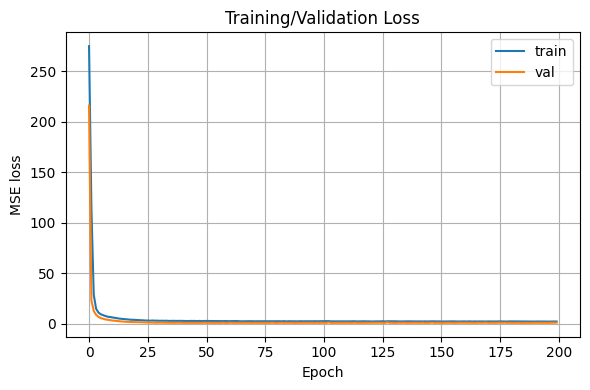

Saved loss plot to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\baseline\plots\loss_curve.png


In [36]:
# Plot loss curves from history
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training/Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
loss_plot_path = PLOTS_DIR / "loss_curve.png"
plt.savefig(loss_plot_path, dpi=150)
plt.show()
print(f"Saved loss plot to {loss_plot_path}")

In [37]:
# Inspect a few test examples: predictions vs targets
num_examples = 20
indices = torch.arange(min(num_examples, X_test_np.shape[0]))
with torch.no_grad():
    preds = model(torch.from_numpy(X_test_np[indices]).to(device)).squeeze(-1).cpu().numpy()

true_log = y_test_np[indices.numpy()]
results_df = pd.DataFrame(
    {
        "name": test_df.iloc[indices]["name"].values,
        "pred_log_gross": preds,
        "true_log_gross": true_log,
        "delta_log_gross": np.abs(preds - true_log),
        "pred_gross": np.expm1(preds),
        "true_gross": np.expm1(true_log),
        "delta_gross": np.abs(np.expm1(preds) - np.expm1(true_log)),
    }
)

with pd.option_context("display.float_format", "{:.2f}".format):
    display(results_df)

print(f"Test MSE: {test_loss:.4f} | Test MAE: {test_mae:.4f}")

,name,pred_log_gross,true_log_gross,delta_log_gross,pred_gross,true_gross,delta_gross
0,Twilight Zone: The Movie,17.15,17.20,0.05,28026488.00,29450940.00,1424452.00
1,No Country for Old Men,18.35,18.96,0.62,92711856.00,171627072.00,78915216.00
2,The Place Beyond the Pines,16.99,17.67,0.68,23913504.00,47052868.00,23139364.00
3,Supercop,14.12,16.60,2.48,1362721.62,16270591.00,14907869.00
4,Zack and Miri Make a Porno,17.64,17.57,0.07,45946060.00,42784308.00,3161752.00
5,The Best of Enemies,15.85,16.14,0.29,7637014.50,10209820.00,2572805.50
6,The Pursuit of D.B. Cooper,14.64,15.12,0.48,2289288.50,3702027.75,1412739.25
7,The Adventures of Tintin,18.96,19.74,0.78,171521376.00,373993856.00,202472480.00
8,The Kiss,13.95,14.44,0.49,1146594.50,1869148.88,722554.38
9,Lethal Weapon 3,18.47,19.59,1.12,104548168.00,321731424.00,217183264.00


Test MSE: 1.1866 | Test MAE: 0.8338


In [38]:
# Persist artifacts: model, training history, metrics, config, and sample predictions
model_path = CHECKPOINT_DIR / "tabular_regressor.pt"
torch.save({"model_state_dict": model.state_dict(), "config": cfg.__dict__, "input_dim": input_dim}, model_path)
print(f"Saved model to {model_path}")

history_path = RESULTS_DIR / "training_history.csv"
pd.DataFrame(history).to_csv(history_path, index=False)
print(f"Saved training history to {history_path}")

metrics_path = RESULTS_DIR / "test_metrics.csv"
pd.DataFrame([
    {"test_mse": float(test_loss), "test_mae": float(test_mae)}
]).to_csv(metrics_path, index=False)
print(f"Saved test metrics to {metrics_path}")

config_path = CONFIG_SNAPSHOT_PATH
with config_path.open("w") as f:
    json.dump({**cfg.__dict__, "artifact_root": str(ARTIFACT_ROOT)}, f, indent=2)
print(f"Saved config to {config_path}")

preds_path = RESULTS_DIR / "sample_predictions.csv"
results_df.to_csv(preds_path, index=False)
print(f"Saved sample predictions to {preds_path}")

Saved model to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\baseline\checkpoints\tabular_regressor.pt
Saved training history to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\baseline\results\training_history.csv
Saved test metrics to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\baseline\results\test_metrics.csv
Saved config to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\baseline\results\config.json
Saved sample predictions to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\baseline\results\sample_predictions.csv
